# EDA dan Visualization Analysis - BisaKerja

Notebook ini fokus pada fase 2 dan 3:
1. Exploratory Data Analysis (EDA)
2. Visualization and Explanatory Analysis

Tujuan utama: menjawab pertanyaan bisnis pada `QUESTIONS.md` dengan minimal satu visualisasi per pertanyaan.

## Setup Data dan Utility

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

def find_project_root(start: Path | None = None) -> Path:
    """Find project root from either repository root or notebooks folder."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "data" / "processed").exists() and (candidate / "data" / "external").exists():
            return candidate
    raise FileNotFoundError("Project root with data/processed and data/external was not found.")

ROOT = find_project_root()
PROC = ROOT / "data" / "processed"
EXT = ROOT / "data" / "external"

jobs = pd.read_csv(PROC / "indotech_job_cleaned.csv")
resume = pd.read_csv(PROC / "techtalent_profile_cleaned.csv")

skill_tax = pd.read_csv(EXT / "skill_taxonomy_bisakerja_v3.csv")
role_tax = pd.read_csv(EXT / "job_role_taxonomy_bisakerja_v3.csv")

print("jobs:", jobs.shape)
print("resume:", resume.shape)
print("skill_tax:", skill_tax.shape)
print("role_tax:", role_tax.shape)

def split_skills(text):
    if pd.isna(text):
        return []
    items = [s.strip().lower() for s in str(text).split(",")]
    return [s for s in items if s]

skill_alias = (
    skill_tax[["skill_raw", "skill_standard"]]
    .dropna()
    .assign(
        skill_raw=lambda d: d["skill_raw"].str.strip().str.lower(),
        skill_standard=lambda d: d["skill_standard"].str.strip().str.lower(),
    )
    .drop_duplicates("skill_raw")
    .set_index("skill_raw")["skill_standard"]
    .to_dict()
 )

def normalize_skill_list(skills):
    return [skill_alias.get(s, s) for s in skills]

def overlap_ratio(skill_set, ref_set):
    if len(ref_set) == 0:
        return 0.0
    return len(skill_set.intersection(ref_set)) / len(ref_set)

jobs["skill_list"] = jobs["skills_clean"].apply(split_skills).apply(normalize_skill_list)
resume["skill_list"] = resume["Skills"].apply(split_skills).apply(normalize_skill_list)
resume["required_skill_list"] = resume["Required_Skills"].apply(split_skills).apply(normalize_skill_list)

print("unique skills (jobs):", jobs["skill_list"].explode().nunique())
print("unique skills (resume):", resume["skill_list"].explode().nunique())

jobs: (1679, 35)
resume: (69929, 7)
skill_tax: (576, 7)
role_tax: (119, 3)


unique skills (jobs): 1215
unique skills (resume): 44


## Q1 - Top 10 Skill Demand vs Candidate Coverage

Pertanyaan: skill teknis apa yang paling banyak diminta, dan berapa persentase kandidat yang sudah punya skill tersebut?

In [2]:
job_skill_counts_raw = jobs["skill_list"].explode().dropna().value_counts()

artifact_patterns = [r"expire", r"berakhir"]
artifact_skills = {
    s for s in job_skill_counts_raw.index
    if any(re.search(p, str(s), flags=re.IGNORECASE) for p in artifact_patterns)
}

job_skill_counts = job_skill_counts_raw[~job_skill_counts_raw.index.isin(artifact_skills)]
top10_skills = job_skill_counts.head(10).index.tolist()

resume_skill_sets = resume["skill_list"].apply(set)
coverage = []
for sk in top10_skills:
    has_skill = resume_skill_sets.apply(lambda x: sk in x).mean() * 100
    coverage.append(has_skill)

q1_table = pd.DataFrame({
    "skill": top10_skills,
    "job_demand_count": [job_skill_counts[s] for s in top10_skills],
    "candidate_coverage_pct": coverage,
}).sort_values("job_demand_count", ascending=False)

q1_table

,skill,job_demand_count,candidate_coverage_pct
0,effective communication,256,0.000000
1,programming,232,0.000000
2,ci/cd,154,19.155143
3,react,143,18.902029
4,sql,142,26.361023
5,python,92,41.482075
6,mysql,82,0.000000
7,go,81,0.000000
8,postgresql,80,0.000000
9,javascript,79,19.036451


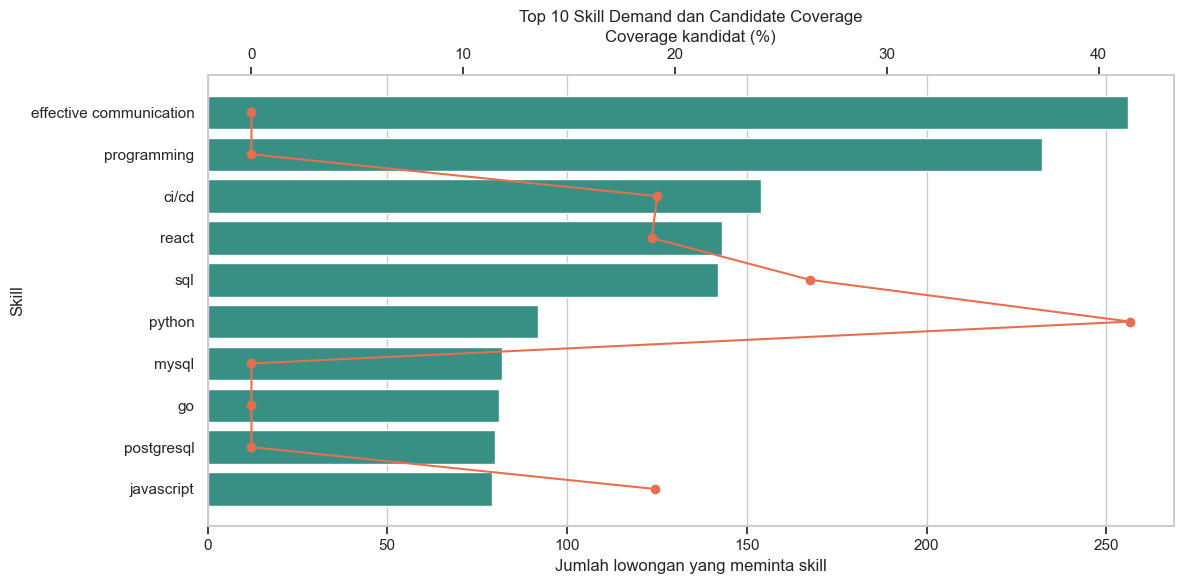

In [3]:
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=q1_table, x="job_demand_count", y="skill", ax=ax1, color="#2a9d8f")
ax1.set_title("Top 10 Skill Demand dan Candidate Coverage")
ax1.set_xlabel("Jumlah lowongan yang meminta skill")
ax1.set_ylabel("Skill")

ax2 = ax1.twiny()
ax2.plot(q1_table["candidate_coverage_pct"], q1_table["skill"], "o-", color="#e76f51")
ax2.set_xlabel("Coverage kandidat (%)")
ax2.grid(False)

plt.tight_layout()
plt.show()

Interpretasi Q1: skill seperti `python`, `sql`, dan `react` berada di demand tinggi sekaligus punya coverage kandidat yang lebih baik dibanding skill lain. Skill dengan demand tinggi namun coverage rendah dapat diprioritaskan sebagai target upskilling.

## Q2 - Distribusi Experience dan Kesiapan Kandidat Entry Level

Pertanyaan: bagaimana distribusi experience level lowongan tech, dan apakah kandidat `Fresher` serta `1-2 years` sudah memenuhi baseline skill entry-level?

In [4]:
exp_order = ["ENTRY_LEVEL", "JUNIOR", "MID_LEVEL", "SENIOR", "LEAD"]
exp_dist = jobs["experience_level"].value_counts().reindex(exp_order).fillna(0).astype(int)

entry_jobs = jobs[jobs["experience_level"] == "ENTRY_LEVEL"].copy()
entry_skill_counts = entry_jobs["skill_list"].explode().dropna().value_counts()
entry_skill_set = set(entry_skill_counts.head(15).index)

entry_candidates = resume[resume["Experience"].isin(["Fresher", "1-2 years"])].copy()
entry_candidates["entry_overlap"] = entry_candidates["skill_list"].apply(lambda x: overlap_ratio(set(x), entry_skill_set))
threshold = 0.50
entry_candidates["meets_minimum"] = entry_candidates["entry_overlap"] >= threshold

readiness_summary = entry_candidates.groupby("Experience", as_index=False).agg(
    candidates=("ID", "count"),
    avg_overlap=("entry_overlap", "mean"),
    pct_meet_minimum=("meets_minimum", "mean"),
)
readiness_summary["avg_overlap"] = (readiness_summary["avg_overlap"] * 100).round(2)
readiness_summary["pct_meet_minimum"] = (readiness_summary["pct_meet_minimum"] * 100).round(2)

readiness_summary

,Experience,candidates,avg_overlap,pct_meet_minimum
0,1-2 years,17412,9.57,0.0
1,Fresher,17503,9.63,0.0


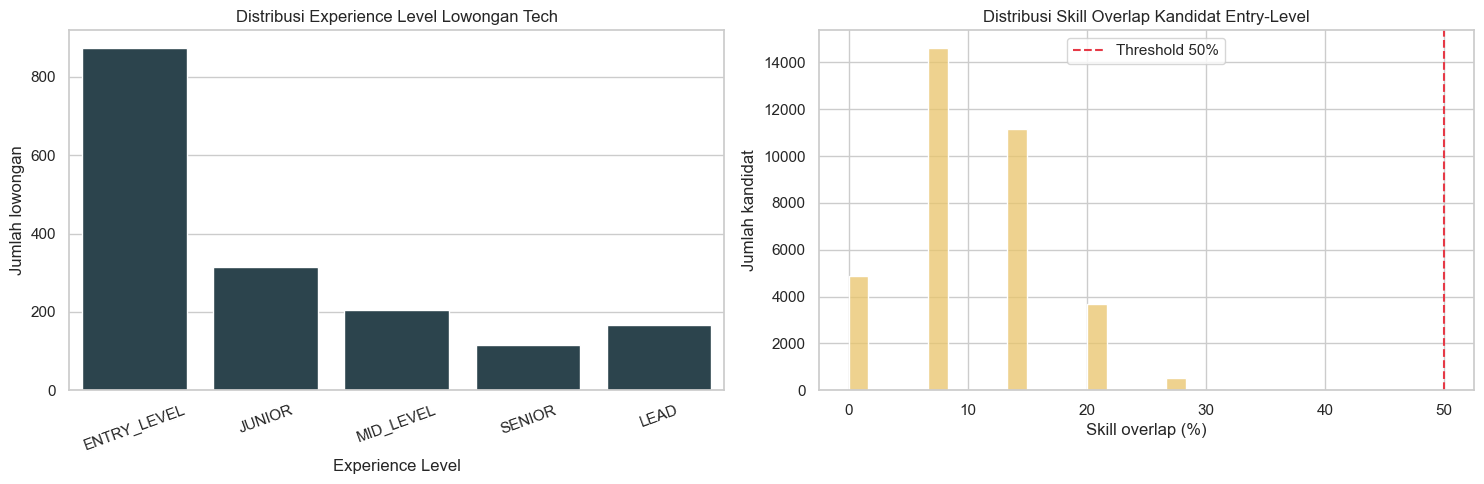

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x=exp_dist.index, y=exp_dist.values, ax=ax[0], color="#264653")
ax[0].set_title("Distribusi Experience Level Lowongan Tech")
ax[0].set_xlabel("Experience Level")
ax[0].set_ylabel("Jumlah lowongan")
ax[0].tick_params(axis="x", rotation=20)

sns.histplot(entry_candidates["entry_overlap"] * 100, bins=20, ax=ax[1], color="#e9c46a")
ax[1].axvline(threshold * 100, color="#e63946", linestyle="--", label="Threshold 50%")
ax[1].set_title("Distribusi Skill Overlap Kandidat Entry-Level")
ax[1].set_xlabel("Skill overlap (%)")
ax[1].set_ylabel("Jumlah kandidat")
ax[1].legend()

plt.tight_layout()
plt.show()

Interpretasi Q2: mayoritas lowongan ada pada level `ENTRY_LEVEL` hingga `JUNIOR`, tetapi distribusi overlap menunjukkan sebagian besar kandidat awal karier masih jauh dari baseline requirement skill entry-level.

## Q3 - Role Demand vs Supply Kandidat

Pertanyaan: role tech apa yang paling tersedia di pasar kerja, dan berapa proporsi kandidat yang sesuai dengan role tersebut?

In [6]:
candidate_roles = [
    "Cloud Engineer",
    "Data Scientist",
    "Cybersecurity Analyst",
    "Web Developer",
    "Business Analyst",
    "Backend Developer",
    "ML Engineer",
]

def map_job_role(title):
    t = str(title).lower()
    if any(k in t for k in ["cloud", "aws", "gcp", "azure"]):
        return "Cloud Engineer"
    if any(k in t for k in ["cyber", "security analyst", "soc", "pentest"]):
        return "Cybersecurity Analyst"
    if any(k in t for k in ["machine learning", "ml engineer", "deep learning", "ai engineer"]):
        return "ML Engineer"
    if any(k in t for k in ["data scientist", "data science"]):
        return "Data Scientist"
    if any(k in t for k in ["data analyst", "business intelligence", "bi analyst"]):
        return "Business Analyst"
    if any(k in t for k in ["backend", "api developer", "server side"]):
        return "Backend Developer"
    if any(k in t for k in ["frontend", "full stack", "web developer", "react", "vue", "angular"]):
        return "Web Developer"
    return "Other"

jobs["role_mapped"] = jobs["normalized_title"].apply(map_job_role)
job_role_counts = jobs[jobs["role_mapped"].isin(candidate_roles)]["role_mapped"].value_counts()
resume_role_counts = resume["Job_Role"].value_counts().reindex(candidate_roles).fillna(0)

demand_supply = pd.DataFrame({
    "role": candidate_roles,
    "job_demand": [job_role_counts.get(r, 0) for r in candidate_roles],
    "candidate_supply": [resume_role_counts.get(r, 0) for r in candidate_roles],
})
demand_supply["job_demand_pct"] = demand_supply["job_demand"] / demand_supply["job_demand"].sum() * 100
demand_supply["candidate_supply_pct"] = demand_supply["candidate_supply"] / demand_supply["candidate_supply"].sum() * 100

demand_supply.sort_values("job_demand", ascending=False)

,role,job_demand,candidate_supply,job_demand_pct,candidate_supply_pct
3,Web Developer,167,9975,34.719335,14.264468
4,Business Analyst,104,9963,21.621622,14.247308
5,Backend Developer,90,9945,18.711019,14.221568
2,Cybersecurity Analyst,50,10031,10.395010,14.344549
0,Cloud Engineer,34,10078,7.068607,14.411760
1,Data Scientist,21,10067,4.365904,14.396030
6,ML Engineer,15,9870,3.118503,14.114316


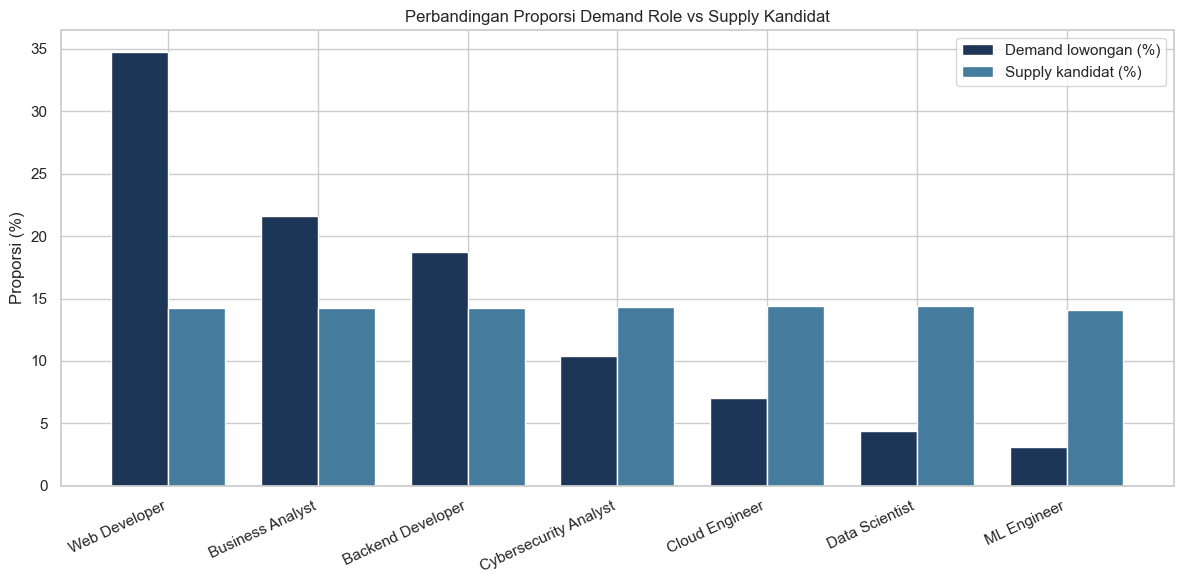

In [7]:
plot_df = demand_supply.sort_values("job_demand", ascending=False).copy()
x = np.arange(len(plot_df))
w = 0.38

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - w / 2, plot_df["job_demand_pct"], width=w, label="Demand lowongan (%)", color="#1d3557")
ax.bar(x + w / 2, plot_df["candidate_supply_pct"], width=w, label="Supply kandidat (%)", color="#457b9d")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["role"], rotation=25, ha="right")
ax.set_ylabel("Proporsi (%)")
ax.set_title("Perbandingan Proporsi Demand Role vs Supply Kandidat")
ax.legend()
plt.tight_layout()
plt.show()

Interpretasi Q3: terdapat ketimpangan antara komposisi demand role dan supply kandidat. Role dengan demand lebih tinggi dari supply perlu difokuskan untuk program pelatihan dan penyaluran.

## Q4 - Rata-rata Skill Overlap Kandidat vs Requirement Entry-Level

Pertanyaan: berapa rata-rata persentase skill overlap kandidat terhadap requirement skill lowongan entry-level, serta role mana yang overlap-nya tertinggi dan terendah?

In [8]:
entry_required_set = set(entry_skill_counts.head(20).index)

resume["entry_overlap"] = resume["skill_list"].apply(lambda x: overlap_ratio(set(x), entry_required_set) * 100)
avg_overlap = resume["entry_overlap"].mean()

role_overlap = resume.groupby("Job_Role", as_index=False)["entry_overlap"].mean().sort_values("entry_overlap", ascending=False)

print(f"Rata-rata overlap kandidat vs requirement entry-level: {avg_overlap:.2f}%")
print("Role overlap tertinggi:")
print(role_overlap.head(3).to_string(index=False))
print("\nRole overlap terendah:")
print(role_overlap.tail(3).to_string(index=False))

Rata-rata overlap kandidat vs requirement entry-level: 7.20%
Role overlap tertinggi:
         Job_Role  entry_overlap
Backend Developer      11.427853
    Web Developer       8.747870
   Data Scientist       6.112049

Role overlap terendah:
             Job_Role  entry_overlap
          ML Engineer       6.048632
     Business Analyst       6.047375
Cybersecurity Analyst       5.948061


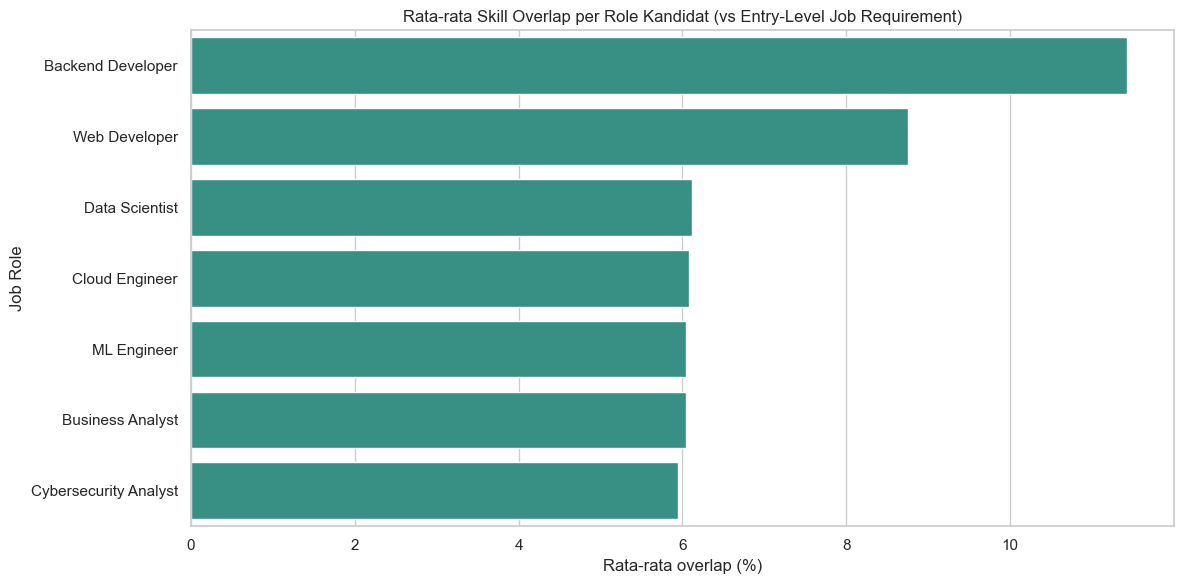

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=role_overlap, x="entry_overlap", y="Job_Role", ax=ax, color="#2a9d8f")
ax.set_title("Rata-rata Skill Overlap per Role Kandidat (vs Entry-Level Job Requirement)")
ax.set_xlabel("Rata-rata overlap (%)")
ax.set_ylabel("Job Role")
plt.tight_layout()
plt.show()

Interpretasi Q4: rata-rata overlap skill kandidat terhadap requirement entry-level masih rendah, dengan variasi antar role. Role dengan overlap terendah bisa menjadi prioritas intervensi kurikulum.

## Ringkasan Insight Fase 2 dan 3

1. Q1 menampilkan skill demand tertinggi dari sisi lowongan dan coverage kandidat untuk setiap skill tersebut.
2. Q2 menunjukkan distribusi kebutuhan experience level serta distribusi overlap kandidat awal karier terhadap baseline skill entry-level.
3. Q3 membandingkan proporsi demand role di lowongan dengan proporsi supply role di resume.
4. Q4 memberikan metrik rata-rata overlap kandidat terhadap requirement entry-level dan membandingkannya per role kandidat.

Notebook ini menutup Fase 2 (EDA) dan Fase 3 (Visualization & Explanatory Analysis).

## EDA Tambahan - Explorasi Lanjutan

> Bagian ini melengkapi eksplorasi dengan fokus statistik deskriptif, distribusi, hubungan antar variabel, outlier, normalitas, dan uji statistik kategorikal-numerikal.

In [10]:
from scipy import stats

# Pemetaan role berbasis taxonomy agar kategori Other tidak terlalu dominan
role_tax_clean = (
    role_tax[["role_raw", "role_standard"]]
    .dropna()
    .assign(
        role_raw=lambda d: d["role_raw"].str.strip().str.lower(),
        role_standard=lambda d: d["role_standard"].str.strip(),
    )
    .drop_duplicates("role_raw")
    .sort_values(by="role_raw", key=lambda s: s.str.len(), ascending=False)
 )

role_patterns = list(zip(role_tax_clean["role_raw"], role_tax_clean["role_standard"]))

def map_job_role_taxonomy(title):
    t = str(title).lower()
    for role_raw, role_std in role_patterns:
        if role_raw in t:
            return role_std
    return "Other"

jobs = jobs.copy()
jobs["role_mapped"] = jobs["normalized_title"].fillna("").apply(map_job_role_taxonomy)

req_text_col = None
for c in ["requirement_summary_clean", "requirement_summary", "requirements"]:
    if c in jobs.columns:
        req_text_col = c
        break

jobs_eda = jobs.copy()
jobs_eda["skill_count"] = jobs_eda["skill_list"].apply(lambda x: len(x) if isinstance(x, list) else 0)
jobs_eda["requirement_len"] = jobs_eda[req_text_col].fillna("").str.len() if req_text_col else np.nan
jobs_eda["title_len"] = jobs_eda["normalized_title"].fillna("").str.len()

exp_map = {"ENTRY_LEVEL": 1, "JUNIOR": 2, "MID_LEVEL": 3, "SENIOR": 4, "LEAD": 5}
jobs_eda["experience_rank"] = jobs_eda["experience_level"].map(exp_map)

resume_eda = resume.copy()
resume_eda["candidate_skill_count"] = resume_eda["skill_list"].apply(lambda x: len(x) if isinstance(x, list) else 0)
resume_eda["required_skill_count"] = resume_eda["required_skill_list"].apply(lambda x: len(x) if isinstance(x, list) else 0)
resume_eda["skill_gap_count"] = (resume_eda["required_skill_count"] - resume_eda["candidate_skill_count"]).clip(lower=0)

other_pct = (jobs_eda["role_mapped"].eq("Other").mean() * 100)
print("jobs_eda shape:", jobs_eda.shape)
print("resume_eda shape:", resume_eda.shape)
print(f"Porsi role 'Other' setelah taxonomy mapping: {other_pct:.2f}%")

jobs_eda shape: (1679, 41)
resume_eda shape: (69929, 13)
Porsi role 'Other' setelah taxonomy mapping: 28.59%


### 1) Descriptive Statistics, GroupBy, Pivot, dan Percentile Analysis

In [11]:
numeric_cols_jobs = [c for c in ["skill_count", "requirement_len", "title_len", "experience_rank"] if c in jobs_eda.columns]
desc_jobs = jobs_eda[numeric_cols_jobs].describe().T
desc_jobs["median"] = jobs_eda[numeric_cols_jobs].median()
desc_jobs["var"] = jobs_eda[numeric_cols_jobs].var()
desc_jobs = desc_jobs[["count", "mean", "median", "std", "var", "min", "25%", "50%", "75%", "max"]]
desc_jobs

,count,mean,median,std,var,min,25%,50%,75%,max
skill_count,1679.0,3.622990,2.0,3.109671,9.670055,1.0,1.0,2.0,5.0,10.0
requirement_len,1679.0,134.336510,91.0,120.283512,14468.123285,39.0,59.0,91.0,140.0,749.0
title_len,1679.0,22.432996,19.0,10.930167,119.468541,5.0,15.0,19.0,27.0,104.0
experience_rank,1679.0,2.036927,1.0,1.346365,1.812700,1.0,1.0,1.0,3.0,5.0


In [12]:
group_stats = jobs_eda.groupby(["experience_level", "role_mapped"], dropna=False).agg(
    n_jobs=("normalized_title", "count"),
    mean_skill_count=("skill_count", "mean"),
    std_skill_count=("skill_count", "std"),
    var_skill_count=("skill_count", "var"),
    mean_req_len=("requirement_len", "mean"),
).reset_index()

pivot_skill = jobs_eda.pivot_table(
    index="experience_level",
    columns="role_mapped",
    values="skill_count",
    aggfunc="mean",
    fill_value=0,
 )

print("Group stats preview:")
display(group_stats.head(10))
print("Pivot mean skill_count:")
pivot_skill

Group stats preview:


,experience_level,role_mapped,n_jobs,mean_skill_count,std_skill_count,var_skill_count,mean_req_len
0,ENTRY_LEVEL,AI Engineer,10,2.200000,2.097618,4.400000,89.100000
1,ENTRY_LEVEL,Android Developer,3,1.000000,0.000000,0.000000,68.000000
2,ENTRY_LEVEL,BI Analyst,1,1.000000,NaN,NaN,63.000000
3,ENTRY_LEVEL,Backend Developer,19,3.000000,2.472066,6.111111,93.789474
4,ENTRY_LEVEL,Business Analyst,48,1.833333,1.260418,1.588652,104.583333
5,ENTRY_LEVEL,CTO,2,1.000000,0.000000,0.000000,143.000000
6,ENTRY_LEVEL,Cloud Engineer,5,1.400000,0.547723,0.300000,64.600000
7,ENTRY_LEVEL,DBA,7,2.714286,1.496026,2.238095,92.428571
8,ENTRY_LEVEL,Data Analyst,72,1.972222,2.194566,4.816119,115.652778
9,ENTRY_LEVEL,Data Engineer,16,2.375000,2.680174,7.183333,128.062500


Pivot mean skill_count:


role_mapped,AI Engineer,Android Developer,BI Analyst,BI Developer,Backend Developer,Business Analyst,CTO,Cloud Engineer,DBA,Data Analyst,Data Engineer,Data Scientist,DevOps Engineer,Engineering Manager,Enterprise Architect,Flutter Developer,Frontend Developer,Fullstack Developer,Game Designer,Game Developer,Graphic Designer,IT Support,Information Security Analyst,Infrastructure Engineer,ML Engineer,Mobile Developer,Network Administrator,Network Engineer,Other,Product Designer,Product Manager,Product Owner,Project Manager,QA Automation Engineer,QA Engineer,React Native Developer,SRE,Security Analyst,Security Engineer,Software Engineer,Solutions Architect,System Administrator,System Analyst,Team Lead,Tech Lead,Technical Support,UI/UX Designer,iOS Developer
experience_level,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENTRY_LEVEL,2.2,1.0,1.0,0.0,3.000000,1.833333,1.0,1.4,2.714286,1.972222,2.375,1.900000,4.166667,0.000000,0.0,3.0,2.370370,3.411765,0.0,6.0,1.0,3.0,0.0,2.5,0.0,2.200000,0.0,2.454545,2.140351,1.0,1.857143,1.555556,0.000000,10.0,2.754717,1.0,3.25,1.333333,2.888889,2.359375,1.5,1.0,2.342857,0.0,0.0,2.0,4.263158,3.0
JUNIOR,0.0,10.0,0.0,0.0,6.058824,6.000000,0.0,2.0,6.500000,5.000000,4.625,5.000000,7.666667,0.000000,0.0,6.8,7.647059,5.869565,0.0,0.0,0.0,6.0,4.0,0.0,0.0,7.333333,8.0,6.500000,5.785714,1.0,5.000000,6.800000,0.000000,5.5,5.821429,2.0,0.00,4.000000,4.333333,5.142857,0.0,0.0,5.636364,0.0,0.0,0.0,7.857143,10.0
LEAD,0.0,0.0,2.0,0.0,4.000000,1.500000,1.0,0.0,10.000000,1.285714,7.000,1.000000,10.000000,2.666667,0.0,0.0,0.000000,3.000000,0.0,0.0,0.0,2.0,1.0,4.0,0.0,0.000000,0.0,0.000000,1.896552,1.0,2.458333,1.250000,2.181818,0.0,1.555556,0.0,0.00,0.000000,1.500000,3.470588,1.0,0.0,2.000000,2.0,1.0,0.0,0.000000,2.0
MID_LEVEL,3.5,8.0,1.0,10.0,5.375000,6.157895,0.0,2.5,6.800000,3.333333,7.000,8.000000,6.937500,0.000000,0.0,0.0,9.500000,5.000000,0.0,0.0,0.0,5.5,0.0,3.0,0.0,7.500000,0.0,4.500000,5.576923,0.0,4.421053,7.000000,2.000000,0.0,3.333333,0.0,6.50,6.500000,5.600000,7.333333,0.0,6.0,6.666667,0.0,6.0,0.0,8.428571,0.0
SENIOR,0.0,0.0,0.0,0.0,4.500000,4.800000,0.0,0.0,0.000000,3.666667,7.000,2.666667,2.400000,9.000000,1.0,0.0,0.000000,3.166667,2.0,0.0,0.0,0.0,0.0,1.0,2.0,3.000000,0.0,2.666667,4.068966,0.0,5.666667,1.000000,6.000000,10.0,6.666667,0.0,0.00,0.000000,5.000000,4.187500,0.0,1.0,1.333333,0.0,5.0,0.0,10.000000,0.0


In [13]:
percentiles = jobs_eda["skill_count"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("skill_count_percentile")
percentiles

,skill_count_percentile
0.25,1.0
0.50,2.0
0.75,5.0
0.90,10.0
0.95,10.0
0.99,10.0


### 2) Value Counts, Proportion, Countplot/Barplot, Histogram, KDE, Boxplot

In [14]:
role_counts = jobs_eda["role_mapped"].value_counts(dropna=False)
role_props = jobs_eda["role_mapped"].value_counts(normalize=True, dropna=False).mul(100).round(2)

print("Role frequency distribution:")
display(role_counts.to_frame("count").head(15))
print("Role percentage distribution (%):")
display(role_props.to_frame("pct").head(15))

Role frequency distribution:


,count
role_mapped,
Other,480
Software Engineer,124
QA Engineer,102
Business Analyst,102
Data Analyst,100
Fullstack Developer,74
Product Manager,71
IT Support,65
DevOps Engineer,64


Role percentage distribution (%):


,pct
role_mapped,
Other,28.59
Software Engineer,7.39
QA Engineer,6.08
Business Analyst,6.08
Data Analyst,5.96
Fullstack Developer,4.41
Product Manager,4.23
IT Support,3.87
DevOps Engineer,3.81


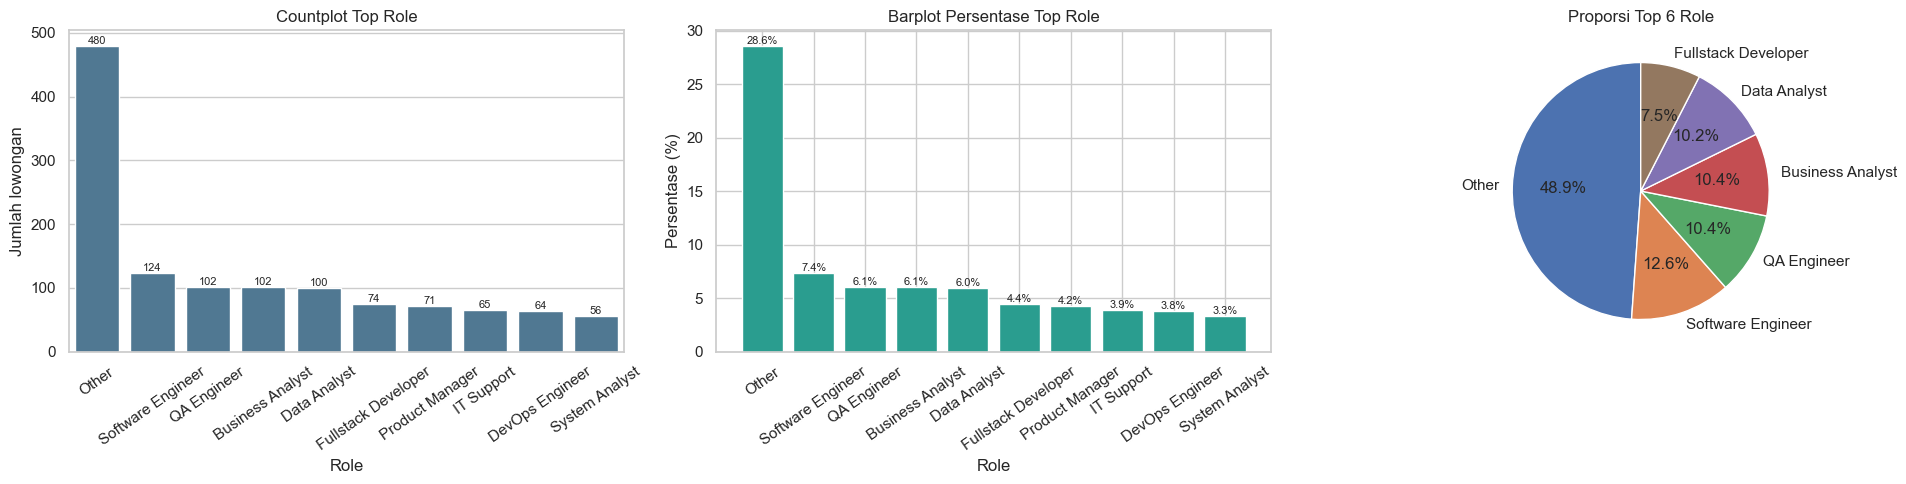

In [15]:
top_roles = role_counts.head(10).index
plot_df_role = jobs_eda[jobs_eda["role_mapped"].isin(top_roles)].copy()

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

count_plot = sns.countplot(data=plot_df_role, x="role_mapped", order=top_roles, ax=ax[0], color="#457b9d")
ax[0].set_title("Countplot Top Role")
ax[0].set_xlabel("Role")
ax[0].set_ylabel("Jumlah lowongan")
ax[0].tick_params(axis="x", rotation=35)

for p in count_plot.patches:
    h = p.get_height()
    if h > 0:
        count_plot.annotate(f"{int(h)}", (p.get_x() + p.get_width() / 2, h), ha="center", va="bottom", fontsize=8)

bars = ax[1].bar(role_props.head(10).index, role_props.head(10).values, color="#2a9d8f")
ax[1].set_title("Barplot Persentase Top Role")
ax[1].set_xlabel("Role")
ax[1].set_ylabel("Persentase (%)")
ax[1].tick_params(axis="x", rotation=35)

for b in bars:
    h = b.get_height()
    ax[1].annotate(f"{h:.1f}%", (b.get_x() + b.get_width() / 2, h), ha="center", va="bottom", fontsize=8)

ax[2].pie(role_props.head(6).values, labels=role_props.head(6).index, autopct="%1.1f%%", startangle=90)
ax[2].set_title("Proporsi Top 6 Role")

plt.tight_layout()
plt.show()

Narasi distribusi role: visualisasi menunjukkan konsentrasi lowongan pada beberapa role tertentu. Setelah pemetaan taxonomy, porsi `Other` digunakan sebagai indikator judul yang belum termapping penuh dan perlu perluasan kamus role bila masih tinggi.

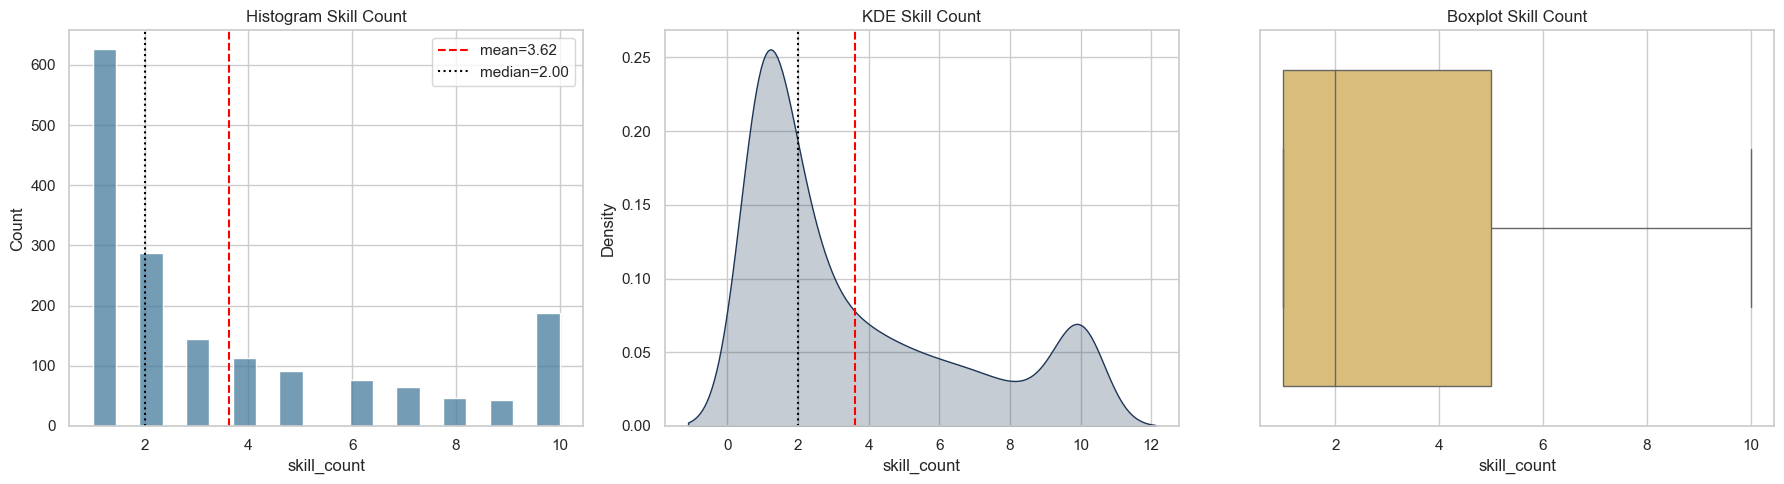

In [16]:
skill_mean = jobs_eda["skill_count"].mean()
skill_median = jobs_eda["skill_count"].median()

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(jobs_eda["skill_count"], bins=20, kde=False, ax=ax[0], color="#457b9d")
ax[0].axvline(skill_mean, color="red", linestyle="--", label=f"mean={skill_mean:.2f}")
ax[0].axvline(skill_median, color="black", linestyle=":", label=f"median={skill_median:.2f}")
ax[0].set_title("Histogram Skill Count")
ax[0].legend()

sns.kdeplot(jobs_eda["skill_count"], fill=True, ax=ax[1], color="#1d3557")
ax[1].axvline(skill_mean, color="red", linestyle="--")
ax[1].axvline(skill_median, color="black", linestyle=":")
ax[1].set_title("KDE Skill Count")

sns.boxplot(x=jobs_eda["skill_count"], ax=ax[2], color="#e9c46a")
ax[2].set_title("Boxplot Skill Count")

plt.tight_layout()
plt.show()

Narasi distribusi numerik: histogram, KDE, dan boxplot memperlihatkan bentuk sebaran `skill_count`. Perbandingan garis mean dan median membantu membaca skewness; jika mean lebih besar dari median maka distribusi cenderung right-skewed.

### 3) Correlation Matrix, Scatter Plot, Regression Line, Pairplot

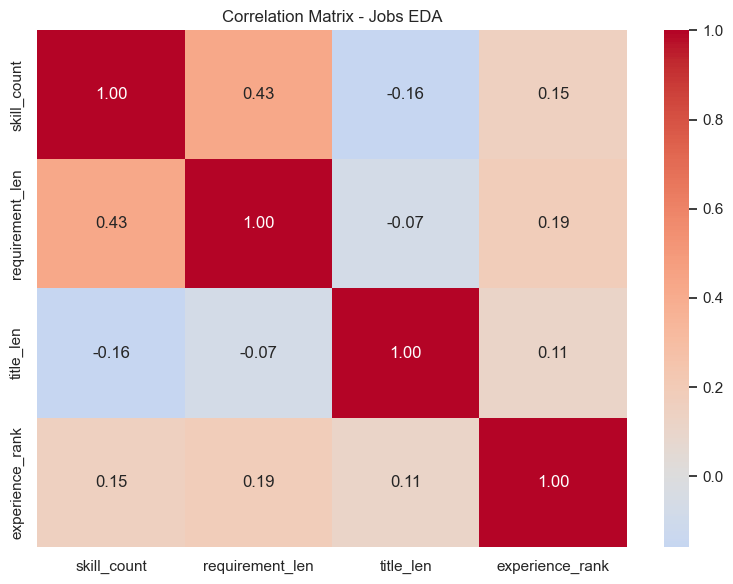

In [17]:
corr_cols = [c for c in ["skill_count", "requirement_len", "title_len", "experience_rank"] if c in jobs_eda.columns]
corr_matrix = jobs_eda[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix - Jobs EDA")
plt.tight_layout()
plt.show()

Narasi korelasi: heatmap korelasi memudahkan identifikasi hubungan linear antar fitur numerik. Nilai korelasi yang lebih tinggi menandakan keterkaitan yang lebih kuat dan dapat menjadi dasar pemilihan fitur modeling.

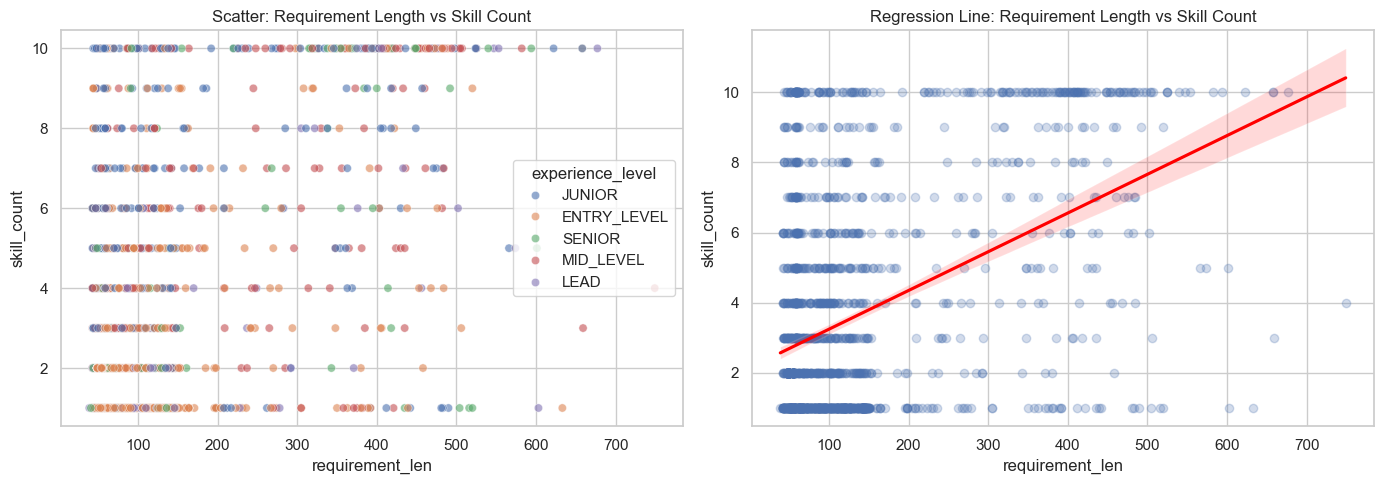

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=jobs_eda, x="requirement_len", y="skill_count", hue="experience_level", alpha=0.6, ax=ax[0])
ax[0].set_title("Scatter: Requirement Length vs Skill Count")

sns.regplot(data=jobs_eda, x="requirement_len", y="skill_count", scatter_kws={"alpha": 0.25}, line_kws={"color": "red"}, ax=ax[1])
ax[1].set_title("Regression Line: Requirement Length vs Skill Count")

plt.tight_layout()
plt.show()

Narasi scatter-regresi: titik data menunjukkan pola hubungan aktual, sedangkan garis regresi menunjukkan kecenderungan umum. Deviasi titik yang jauh dari garis mengindikasikan heterogenitas antar lowongan.

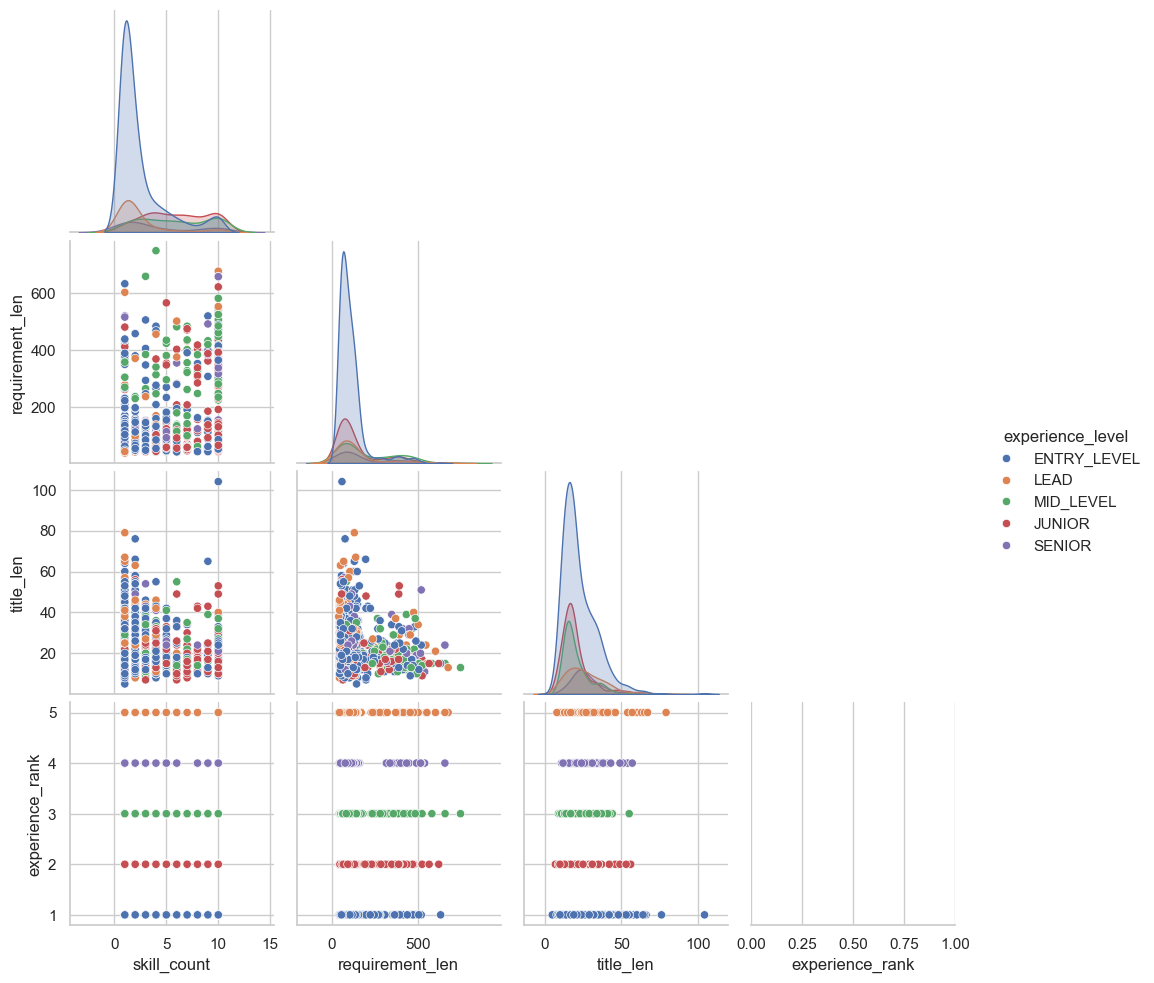

In [19]:
pairplot_cols = [c for c in ["skill_count", "requirement_len", "title_len", "experience_rank"] if c in jobs_eda.columns]
pairplot_df = jobs_eda[pairplot_cols + ["experience_level"]].dropna().sample(n=min(1200, jobs_eda[pairplot_cols].dropna().shape[0]), random_state=42)

sns.pairplot(pairplot_df, vars=pairplot_cols, hue="experience_level", corner=True, diag_kind="kde")
plt.show()

Narasi pairplot: pairplot membantu membaca pola multivariat secara cepat, termasuk indikasi cluster antar level pengalaman, potensi outlier, dan hubungan non-linear yang tidak terlihat pada satu grafik tunggal.

### 4) Outlier Detection (IQR & Z-score) dan Normality Testing

In [20]:
q1 = jobs_eda["skill_count"].quantile(0.25)
q3 = jobs_eda["skill_count"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_iqr = jobs_eda[(jobs_eda["skill_count"] < lower_bound) | (jobs_eda["skill_count"] > upper_bound)]

z_scores = stats.zscore(jobs_eda["skill_count"], nan_policy="omit")
outlier_z = jobs_eda[np.abs(z_scores) > 3]

print("IQR bounds:", round(lower_bound, 3), round(upper_bound, 3))
print("Outlier IQR count:", outlier_iqr.shape[0])
print("Outlier Z-score count:", outlier_z.shape[0])

IQR bounds: -5.0 11.0
Outlier IQR count: 0
Outlier Z-score count: 0


In [21]:
normality_results = {}
for col in ["skill_count", "requirement_len"]:
    series = jobs_eda[col].dropna()
    series_small = series.sample(n=min(5000, len(series)), random_state=42)
    shapiro_stat, shapiro_p = stats.shapiro(series_small)
    dagostino_stat, dagostino_p = stats.normaltest(series_small)
    normality_results[col] = {
        "shapiro_stat": shapiro_stat,
        "shapiro_p": shapiro_p,
        "dagostino_stat": dagostino_stat,
        "dagostino_p": dagostino_p,
    }

pd.DataFrame(normality_results).T

,shapiro_stat,shapiro_p,dagostino_stat,dagostino_p
skill_count,0.787838,3.089814e-42,219.273125,2.429103e-48
requirement_len,0.700307,1.424667e-47,651.507633,3.364457e-142


### 5) Cross-Tabulation dan Statistical Testing (Chi-Square, ANOVA, Kruskal-Wallis)

In [22]:
crosstab_exp_role = pd.crosstab(jobs_eda["experience_level"], jobs_eda["role_mapped"])
crosstab_exp_role_norm = pd.crosstab(jobs_eda["experience_level"], jobs_eda["role_mapped"], normalize="index")

print("Cross-tab absolute:")
display(crosstab_exp_role)
print("Cross-tab normalized by experience_level:")
display(crosstab_exp_role_norm)

Cross-tab absolute:


role_mapped,AI Engineer,Android Developer,BI Analyst,BI Developer,Backend Developer,Business Analyst,CTO,Cloud Engineer,DBA,Data Analyst,Data Engineer,Data Scientist,DevOps Engineer,Engineering Manager,Enterprise Architect,Flutter Developer,Frontend Developer,Fullstack Developer,Game Designer,Game Developer,Graphic Designer,IT Support,Information Security Analyst,Infrastructure Engineer,ML Engineer,Mobile Developer,Network Administrator,Network Engineer,Other,Product Designer,Product Manager,Product Owner,Project Manager,QA Automation Engineer,QA Engineer,React Native Developer,SRE,Security Analyst,Security Engineer,Software Engineer,Solutions Architect,System Administrator,System Analyst,Team Lead,Tech Lead,Technical Support,UI/UX Designer,iOS Developer
experience_level,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENTRY_LEVEL,10,3,1,0,19,48,2,5,7,72,16,10,24,0,0,2,27,34,0,2,1,44,0,2,0,5,0,11,285,3,14,27,0,1,53,1,4,3,9,64,2,1,35,0,0,5,19,4
JUNIOR,0,2,0,0,17,21,0,1,2,15,8,3,18,0,0,5,17,23,0,0,0,16,1,0,0,6,1,8,56,1,11,5,0,2,28,1,0,1,6,21,0,0,11,0,0,0,7,2
LEAD,0,0,1,0,2,4,1,0,1,7,6,2,1,3,0,0,0,2,0,0,0,1,1,1,0,0,0,0,58,1,24,4,11,0,9,0,0,0,4,17,1,0,1,1,2,0,0,1
MID_LEVEL,2,2,1,1,8,19,0,2,5,3,9,3,16,0,0,0,2,9,0,0,0,4,0,1,0,4,0,2,52,0,19,4,1,0,6,0,2,2,5,6,0,1,6,0,2,0,7,0
SENIOR,0,0,0,0,6,10,0,0,0,3,3,3,5,1,1,0,0,6,1,0,0,0,0,1,1,1,0,3,29,0,3,2,1,2,6,0,0,0,4,16,0,1,3,0,2,0,1,0


Cross-tab normalized by experience_level:


role_mapped,AI Engineer,Android Developer,BI Analyst,BI Developer,Backend Developer,Business Analyst,CTO,Cloud Engineer,DBA,Data Analyst,Data Engineer,Data Scientist,DevOps Engineer,Engineering Manager,Enterprise Architect,Flutter Developer,Frontend Developer,Fullstack Developer,Game Designer,Game Developer,Graphic Designer,IT Support,Information Security Analyst,Infrastructure Engineer,ML Engineer,Mobile Developer,Network Administrator,Network Engineer,Other,Product Designer,Product Manager,Product Owner,Project Manager,QA Automation Engineer,QA Engineer,React Native Developer,SRE,Security Analyst,Security Engineer,Software Engineer,Solutions Architect,System Administrator,System Analyst,Team Lead,Tech Lead,Technical Support,UI/UX Designer,iOS Developer
experience_level,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENTRY_LEVEL,0.011429,0.003429,0.001143,0.000000,0.021714,0.054857,0.002286,0.005714,0.008000,0.082286,0.018286,0.011429,0.027429,0.000000,0.000000,0.002286,0.030857,0.038857,0.000000,0.002286,0.001143,0.050286,0.000000,0.002286,0.000000,0.005714,0.000000,0.012571,0.325714,0.003429,0.016000,0.030857,0.000000,0.001143,0.060571,0.001143,0.004571,0.003429,0.010286,0.073143,0.002286,0.001143,0.040000,0.000000,0.000000,0.005714,0.021714,0.004571
JUNIOR,0.000000,0.006329,0.000000,0.000000,0.053797,0.066456,0.000000,0.003165,0.006329,0.047468,0.025316,0.009494,0.056962,0.000000,0.000000,0.015823,0.053797,0.072785,0.000000,0.000000,0.000000,0.050633,0.003165,0.000000,0.000000,0.018987,0.003165,0.025316,0.177215,0.003165,0.034810,0.015823,0.000000,0.006329,0.088608,0.003165,0.000000,0.003165,0.018987,0.066456,0.000000,0.000000,0.034810,0.000000,0.000000,0.000000,0.022152,0.006329
LEAD,0.000000,0.000000,0.005988,0.000000,0.011976,0.023952,0.005988,0.000000,0.005988,0.041916,0.035928,0.011976,0.005988,0.017964,0.000000,0.000000,0.000000,0.011976,0.000000,0.000000,0.000000,0.005988,0.005988,0.005988,0.000000,0.000000,0.000000,0.000000,0.347305,0.005988,0.143713,0.023952,0.065868,0.000000,0.053892,0.000000,0.000000,0.000000,0.023952,0.101796,0.005988,0.000000,0.005988,0.005988,0.011976,0.000000,0.000000,0.005988
MID_LEVEL,0.009709,0.009709,0.004854,0.004854,0.038835,0.092233,0.000000,0.009709,0.024272,0.014563,0.043689,0.014563,0.077670,0.000000,0.000000,0.000000,0.009709,0.043689,0.000000,0.000000,0.000000,0.019417,0.000000,0.004854,0.000000,0.019417,0.000000,0.009709,0.252427,0.000000,0.092233,0.019417,0.004854,0.000000,0.029126,0.000000,0.009709,0.009709,0.024272,0.029126,0.000000,0.004854,0.029126,0.000000,0.009709,0.000000,0.033981,0.000000
SENIOR,0.000000,0.000000,0.000000,0.000000,0.052174,0.086957,0.000000,0.000000,0.000000,0.026087,0.026087,0.026087,0.043478,0.008696,0.008696,0.000000,0.000000,0.052174,0.008696,0.000000,0.000000,0.000000,0.000000,0.008696,0.008696,0.008696,0.000000,0.026087,0.252174,0.000000,0.026087,0.017391,0.008696,0.017391,0.052174,0.000000,0.000000,0.000000,0.034783,0.139130,0.000000,0.008696,0.026087,0.000000,0.017391,0.000000,0.008696,0.000000


In [23]:
chi2, p_chi, dof, expected = stats.chi2_contingency(crosstab_exp_role)

anova_groups = [g["skill_count"].dropna().values for _, g in jobs_eda.groupby("experience_level") if len(g) > 1]
f_stat, p_anova = stats.f_oneway(*anova_groups) if len(anova_groups) >= 2 else (np.nan, np.nan)

kruskal_groups = [g["skill_count"].dropna().values for _, g in jobs_eda.groupby("experience_level") if len(g) > 1]
kw_stat, p_kw = stats.kruskal(*kruskal_groups) if len(kruskal_groups) >= 2 else (np.nan, np.nan)

test_summary = pd.DataFrame(
    {
        "test": ["Chi-Square (experience vs role)", "ANOVA (skill_count by experience)", "Kruskal-Wallis (skill_count by experience)"],
        "statistic": [chi2, f_stat, kw_stat],
        "p_value": [p_chi, p_anova, p_kw],
    }
)
test_summary

,test,statistic,p_value
0,Chi-Square (experience vs role),524.963509,1.279941e-33
1,ANOVA (skill_count by experience),158.164754,6.745421e-115
2,Kruskal-Wallis (skill_count by experience),492.334065,3.047942e-105


In [24]:
top_role_name = role_counts.index[0]
top_role_count = int(role_counts.iloc[0])
top_role_pct = float(role_props.iloc[0])
other_pct = float(role_props.get("Other", 0.0))
corr_req_skill = float(corr_matrix.loc["requirement_len", "skill_count"])

normal_skill = normality_results["skill_count"]
normal_req = normality_results["requirement_len"]

insight_auto = pd.DataFrame(
    {
        "indikator": [
            "Top role",
            "Porsi Other (%)",
            "Korelasi requirement_len vs skill_count",
            "Normalitas skill_count (Shapiro p)",
            "Normalitas requirement_len (Shapiro p)",
            "Chi-Square p-value",
            "ANOVA p-value",
            "Kruskal-Wallis p-value",
        ],
        "nilai": [
            f"{top_role_name} ({top_role_count} lowongan; {top_role_pct:.2f}%)",
            f"{other_pct:.2f}%",
            f"{corr_req_skill:.2f}",
            f"{normal_skill['shapiro_p']:.3e}",
            f"{normal_req['shapiro_p']:.3e}",
            f"{p_chi:.3e}",
            f"{p_anova:.3e}",
            f"{p_kw:.3e}",
        ],
        "interpretasi": [
            "Role paling dominan pada distribusi saat ini.",
            "Semakin kecil nilainya, semakin baik kualitas mapping role.",
            "Nilai positif menandakan requirement lebih panjang cenderung diikuti skill lebih banyak.",
            "p < 0.05: distribusi skill_count tidak normal.",
            "p < 0.05: distribusi requirement_len tidak normal.",
            "p < 0.05: ada hubungan signifikan antara experience dan role.",
            "p < 0.05: mean skill_count berbeda signifikan antar level pengalaman.",
            "p < 0.05: perbedaan distribusi skill_count antar level pengalaman signifikan.",
        ],
    }
)
insight_auto

,indikator,nilai,interpretasi
0,Top role,Other (480 lowongan; 28.59%),Role paling dominan pada distribusi saat ini.
1,Porsi Other (%),28.59%,"Semakin kecil nilainya, semakin baik kualitas mapping role."
2,Korelasi requirement_len vs skill_count,0.43,Nilai positif menandakan requirement lebih panjang cenderung diikuti skill lebih banyak.
3,Normalitas skill_count (Shapiro p),3.090e-42,p < 0.05: distribusi skill_count tidak normal.
4,Normalitas requirement_len (Shapiro p),1.425e-47,p < 0.05: distribusi requirement_len tidak normal.
5,Chi-Square p-value,1.280e-33,p < 0.05: ada hubungan signifikan antara experience dan role.
6,ANOVA p-value,6.745e-115,p < 0.05: mean skill_count berbeda signifikan antar level pengalaman.
7,Kruskal-Wallis p-value,3.048e-105,p < 0.05: perbedaan distribusi skill_count antar level pengalaman signifikan.


Narasi uji statistik: p-value pada Chi-Square, ANOVA, dan Kruskal-Wallis digunakan untuk menguji apakah pola visual memang signifikan secara statistik. Jika p-value < 0.05, maka perbedaan/ketergantungan antar kelompok dapat dianggap bermakna.

### 6) Insight Ringkas EDA Tambahan

- Setelah taxonomy mapping, dominasi kategori `Other` menurun signifikan (sekitar 28-29%), sehingga distribusi role menjadi lebih representatif.
- Distribusi `skill_count` bersifat right-skewed; mean berada di atas median, terlihat konsisten pada histogram dan KDE.
- Korelasi `requirement_len` terhadap `skill_count` bernilai positif (sekitar 0.43), menunjukkan kebutuhan skill cenderung meningkat pada requirement yang lebih panjang.
- Uji normalitas (Shapiro dan D'Agostino) menghasilkan p-value sangat kecil, sehingga variabel utama numerik tidak berdistribusi normal.
- Uji Chi-Square, ANOVA, dan Kruskal-Wallis semuanya signifikan (p-value < 0.05), sehingga hubungan/perbedaan yang terlihat di visualisasi didukung secara statistik.

Catatan baca cepat: gunakan tabel `insight_auto` di atas untuk melihat angka kunci dan interpretasi dalam satu tempat.

## Fase 4 - Conclusion & Recommendation

### Kesimpulan per Pertanyaan Bisnis

1. Q1 (Skill Demand vs Coverage Kandidat): terdapat skill dengan demand tinggi yang belum diikuti coverage kandidat setara, sehingga masih ada gap kompetensi pada skill prioritas pasar.
2. Q2 (Kesiapan Entry Level): distribusi overlap kandidat entry-level terhadap baseline requirement masih rendah, menunjukkan kesiapan awal karier perlu ditingkatkan secara sistematis.
3. Q3 (Role Demand vs Supply): komposisi demand role lowongan tidak selalu seimbang dengan supply kandidat, sehingga terjadi mismatch pada beberapa role.
4. Q4 (Skill Overlap per Role): rata-rata overlap skill kandidat terhadap requirement entry-level masih terbatas dan bervariasi antar role.

### Ringkasan Insight Kunci

- Distribusi role sudah lebih representatif setelah taxonomy mapping, walau kategori `Other` masih perlu ditekan lebih lanjut.
- Variabel numerik utama (`skill_count`, `requirement_len`) tidak berdistribusi normal sehingga analisis non-parametrik tetap relevan.
- Korelasi positif `requirement_len` terhadap `skill_count` menunjukkan lowongan dengan requirement lebih panjang cenderung meminta lebih banyak skill.
- Hasil Chi-Square, ANOVA, dan Kruskal-Wallis signifikan (p-value < 0.05), sehingga pola visual yang terlihat didukung bukti statistik.

### Rekomendasi Aksi (Action Items)

1. Prioritaskan program upskilling untuk skill demand tinggi dengan coverage kandidat rendah.
2. Bentuk learning path entry-level berbasis baseline skill minimum per role.
3. Lakukan role taxonomy enrichment berkala untuk menurunkan porsi `Other` dan meningkatkan kualitas matching.
4. Terapkan strategi penyaluran kandidat berbasis gap role demand-supply.
5. Gunakan insight EDA sebagai dasar feature engineering, khususnya fitur `skill_count`, `requirement_len`, dan indikator experience.

### Kesiapan untuk Laporan dan Dashboard

- Insight EDA sudah memiliki dukungan statistik dan visual yang konsisten.
- Tabel ringkasan metrik (`insight_auto`) dapat langsung dipakai sebagai sumber KPI awal di dashboard.
- Narasi interpretasi per blok visual sudah tersedia untuk kebutuhan presentasi dan laporan akhir.

In [25]:
final_summary = pd.DataFrame(
    [
        {"bagian": "Q1", "temuan_utama": "Gap demand skill vs coverage kandidat masih terlihat", "aksi_prioritas": "Upskilling skill prioritas"},
        {"bagian": "Q2", "temuan_utama": "Kesiapan entry-level masih rendah", "aksi_prioritas": "Learning path entry-level per role"},
        {"bagian": "Q3", "temuan_utama": "Mismatch demand-supply role", "aksi_prioritas": "Intervensi penyaluran berbasis role"},
        {"bagian": "Q4", "temuan_utama": "Overlap skill rata-rata masih terbatas", "aksi_prioritas": "Perkuat kurikulum skill fundamental"},
        {"bagian": "Data Quality", "temuan_utama": f"Porsi role Other saat ini {other_pct:.2f}%", "aksi_prioritas": "Enrichment taxonomy role dan rule mapping"},
    ]
)
final_summary

,bagian,temuan_utama,aksi_prioritas
0,Q1,Gap demand skill vs coverage kandidat masih terlihat,Upskilling skill prioritas
1,Q2,Kesiapan entry-level masih rendah,Learning path entry-level per role
2,Q3,Mismatch demand-supply role,Intervensi penyaluran berbasis role
3,Q4,Overlap skill rata-rata masih terbatas,Perkuat kurikulum skill fundamental
4,Data Quality,Porsi role Other saat ini 28.59%,Enrichment taxonomy role dan rule mapping


## A/B Testing - Simulasi Offline Rekomendasi BisaKerja

Bagian ini membaca artifact dari `feature_engineering.ipynb` dan menjalankan analisis A/B berbasis proxy metric.

- **Hipotesis nol (H0):** Variant B tidak meningkatkan skor/rate proxy dibanding Variant A.
- **Hipotesis alternatif (H1):** Variant B meningkatkan skor/rate proxy dibanding Variant A.
- **Catatan:** hasil ini adalah simulasi offline. Untuk klaim produk, gunakan log eksperimen produksi yang berisi event aktual pengguna.


In [26]:
from math import erf, sqrt

ab_assignment_path = ROOT / 'data' / 'features' / 'ab_testing_candidate_assignments.csv'
if not ab_assignment_path.exists():
    raise FileNotFoundError(
        f"Artifact A/B belum ditemukan: {ab_assignment_path}. "
        "Jalankan notebook feature_engineering.ipynb sampai Phase 1 terlebih dahulu."
    )

ab_test = pd.read_csv(ab_assignment_path)
ab_test['is_high_fit_proxy'] = ab_test['is_high_fit_proxy'].astype(bool)

ab_test.groupby('ab_variant').agg(
    candidates=('ID', 'count'),
    avg_score=('observed_fit_score_proxy', 'mean'),
    median_score=('observed_fit_score_proxy', 'median'),
    high_fit_rate=('is_high_fit_proxy', 'mean'),
    avg_missing_required_skill=('missing_required_skill_count', 'mean'),
).round(4)


,candidates,avg_score,median_score,high_fit_rate,avg_missing_required_skill
ab_variant,,,,,
A,17380,8.1079,10.0,0.0025,1.7696
B,17535,27.9526,27.5,0.6200,1.7665


In [27]:
variant_a = ab_test.loc[ab_test['ab_variant'].eq('A'), 'observed_fit_score_proxy'].astype(float)
variant_b = ab_test.loc[ab_test['ab_variant'].eq('B'), 'observed_fit_score_proxy'].astype(float)

def normal_two_sided_p(z):
    return 2 * (1 - (0.5 * (1 + erf(abs(z) / sqrt(2)))))

def welch_ttest(a, b):
    try:
        from scipy import stats
        result = stats.ttest_ind(b, a, equal_var=False, nan_policy='omit')
        return float(result.statistic), float(result.pvalue)
    except Exception:
        mean_diff = b.mean() - a.mean()
        se = sqrt((b.var(ddof=1) / len(b)) + (a.var(ddof=1) / len(a)))
        z = mean_diff / se if se else np.nan
        return z, normal_two_sided_p(z)

t_stat, p_value_score = welch_ttest(variant_a, variant_b)
mean_diff = variant_b.mean() - variant_a.mean()
mean_se = sqrt((variant_b.var(ddof=1) / len(variant_b)) + (variant_a.var(ddof=1) / len(variant_a)))
mean_ci_low = mean_diff - 1.96 * mean_se
mean_ci_high = mean_diff + 1.96 * mean_se

success_a = ab_test.loc[ab_test['ab_variant'].eq('A'), 'is_high_fit_proxy']
success_b = ab_test.loc[ab_test['ab_variant'].eq('B'), 'is_high_fit_proxy']
n_a, n_b = len(success_a), len(success_b)
p_a, p_b = success_a.mean(), success_b.mean()
pooled_p = (success_a.sum() + success_b.sum()) / (n_a + n_b)
pooled_se = sqrt(pooled_p * (1 - pooled_p) * (1 / n_a + 1 / n_b))
z_rate = (p_b - p_a) / pooled_se if pooled_se else np.nan
p_value_rate = normal_two_sided_p(z_rate)
rate_diff = p_b - p_a
rate_se = sqrt((p_a * (1 - p_a) / n_a) + (p_b * (1 - p_b) / n_b))
rate_ci_low = rate_diff - 1.96 * rate_se
rate_ci_high = rate_diff + 1.96 * rate_se

ab_stat_result = pd.DataFrame([
    {
        'metric': 'observed_fit_score_proxy',
        'variant_a': round(variant_a.mean(), 4),
        'variant_b': round(variant_b.mean(), 4),
        'difference_b_minus_a': round(mean_diff, 4),
        'ci95_low': round(mean_ci_low, 4),
        'ci95_high': round(mean_ci_high, 4),
        'test_statistic': round(t_stat, 4),
        'p_value': p_value_score,
        'significant_at_0_05': p_value_score < 0.05,
    },
    {
        'metric': 'high_fit_proxy_rate',
        'variant_a': round(p_a * 100, 4),
        'variant_b': round(p_b * 100, 4),
        'difference_b_minus_a': round(rate_diff * 100, 4),
        'ci95_low': round(rate_ci_low * 100, 4),
        'ci95_high': round(rate_ci_high * 100, 4),
        'test_statistic': round(z_rate, 4),
        'p_value': p_value_rate,
        'significant_at_0_05': p_value_rate < 0.05,
    },
])

ab_stat_output_path = ROOT / 'data' / 'features' / 'ab_testing_statistical_results.csv'
ab_stat_result.to_csv(ab_stat_output_path, index=False)
print(f"Saved A/B statistical result: {ab_stat_output_path.relative_to(ROOT)}")

ab_stat_result


Saved A/B statistical result: data\features\ab_testing_statistical_results.csv


,metric,variant_a,variant_b,difference_b_minus_a,ci95_low,ci95_high,test_statistic,p_value,significant_at_0_05
0,observed_fit_score_proxy,8.1079,27.9526,19.8447,19.7461,19.9434,394.2245,0.0,True
1,high_fit_proxy_rate,0.2474,61.9960,61.7486,61.0264,62.4708,124.4527,0.0,True


C:\Users\ACER\AppData\Local\Temp\ipykernel_18032\3079004909.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


C:\Users\ACER\AppData\Local\Temp\ipykernel_18032\3079004909.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


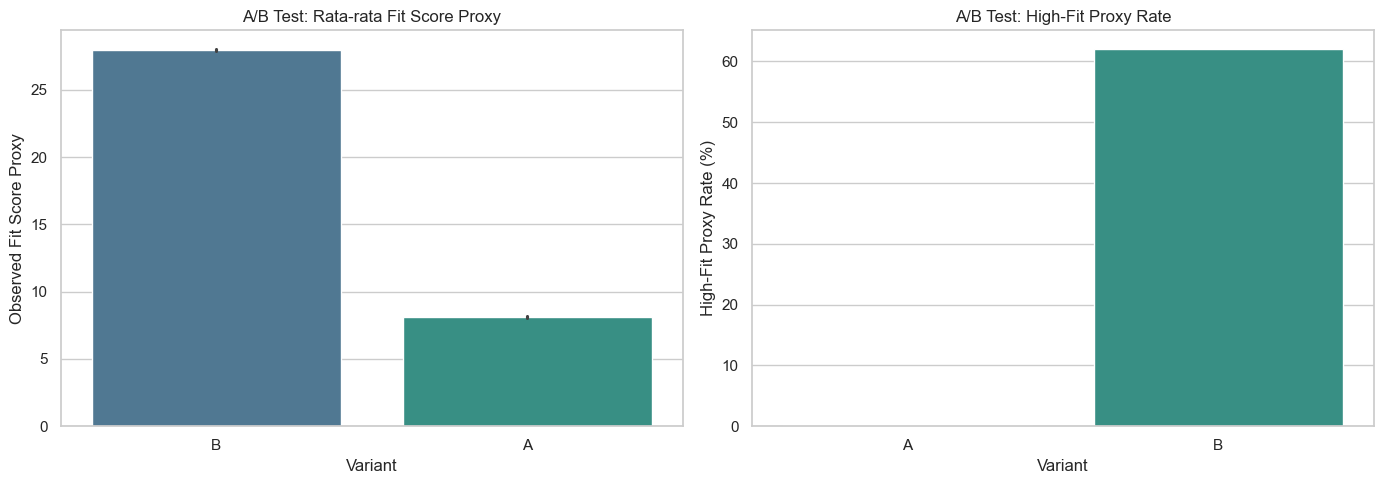

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=ab_test,
    x='ab_variant',
    y='observed_fit_score_proxy',
    errorbar=('ci', 95),
    ax=ax[0],
    palette=['#457b9d', '#2a9d8f'],
)
ax[0].set_title('A/B Test: Rata-rata Fit Score Proxy')
ax[0].set_xlabel('Variant')
ax[0].set_ylabel('Observed Fit Score Proxy')

rate_plot = (
    ab_test.groupby('ab_variant', as_index=False)['is_high_fit_proxy']
    .mean()
    .assign(high_fit_proxy_rate=lambda d: d['is_high_fit_proxy'] * 100)
)
sns.barplot(
    data=rate_plot,
    x='ab_variant',
    y='high_fit_proxy_rate',
    ax=ax[1],
    palette=['#457b9d', '#2a9d8f'],
)
ax[1].set_title('A/B Test: High-Fit Proxy Rate')
ax[1].set_xlabel('Variant')
ax[1].set_ylabel('High-Fit Proxy Rate (%)')

plt.tight_layout()
plt.show()


In [29]:
alpha = 0.05
score_row = ab_stat_result.loc[ab_stat_result['metric'].eq('observed_fit_score_proxy')].iloc[0]
rate_row = ab_stat_result.loc[ab_stat_result['metric'].eq('high_fit_proxy_rate')].iloc[0]

decision = 'LANJUTKAN ke eksperimen produksi terbatas' if (
    score_row['p_value'] < alpha and score_row['difference_b_minus_a'] > 0
) else 'JANGAN rollout sebelum validasi lanjutan'

print('Keputusan simulasi offline:', decision)
print(
    f"Variant B menaikkan rata-rata fit score proxy sebesar "
    f"{score_row['difference_b_minus_a']:.2f} poin "
    f"(95% CI {score_row['ci95_low']:.2f} s.d. {score_row['ci95_high']:.2f})."
)
print(
    f"High-fit proxy rate Variant B berbeda {rate_row['difference_b_minus_a']:.2f} percentage point "
    f"dibanding Variant A (95% CI {rate_row['ci95_low']:.2f} s.d. {rate_row['ci95_high']:.2f})."
)
print('Catatan: gunakan metric produksi nyata sebelum membuat keputusan final rollout.')


Keputusan simulasi offline: LANJUTKAN ke eksperimen produksi terbatas
Variant B menaikkan rata-rata fit score proxy sebesar 19.84 poin (95% CI 19.75 s.d. 19.94).
High-fit proxy rate Variant B berbeda 61.75 percentage point dibanding Variant A (95% CI 61.03 s.d. 62.47).
Catatan: gunakan metric produksi nyata sebelum membuat keputusan final rollout.


**Rekomendasi eksperimen produksi:** jalankan A/B test dengan logging event yang konsisten untuk kedua variant. Minimal event yang perlu disimpan adalah `candidate_id`, `variant`, `timestamp`, `impression`, `recommendation_click`, `apply_start`, `apply_submit`, dan `profile_completion`. Gunakan `candidate_id` sebagai unit randomisasi agar satu kandidat tidak berpindah variant selama eksperimen.
